Bài tập 1



In [2]:
import pandas as pd


df = pd.read_csv("/content/sinh_vien.csv")

# Tổng số sinh viên
tong_so_sinh_vien = len(df)

# Lọc nhóm sinh viên có điểm giữa kỳ từ 7 trở lên
nhom_diem_cao = df[df["diem_giua_ky"] >= 7]

# Số sinh viên trong nhóm
so_sinh_vien_diem_cao = len(nhom_diem_cao)

# Đếm số sinh viên qua môn và rớt môn trong nhóm
so_sinh_vien_qua_mon = (nhom_diem_cao["qua_mon"] == 1).sum()
so_sinh_vien_rot_mon = (nhom_diem_cao["qua_mon"] == 0).sum()

# Tính tỷ lệ qua môn
ty_le_qua_mon = nhom_diem_cao["qua_mon"].mean()

# In kết quả
print("Tổng số sinh viên:", tong_so_sinh_vien)
print("Số sinh viên có điểm giữa kỳ từ 7 trở lên:", so_sinh_vien_diem_cao)
print("Số sinh viên qua môn trong nhóm:", so_sinh_vien_qua_mon)
print("Số sinh viên rớt môn trong nhóm:", so_sinh_vien_rot_mon)
print("Tỷ lệ qua môn:", ty_le_qua_mon)
print("Tỷ lệ qua môn (%):", ty_le_qua_mon * 100)

Tổng số sinh viên: 120
Số sinh viên có điểm giữa kỳ từ 7 trở lên: 31
Số sinh viên qua môn trong nhóm: 28
Số sinh viên rớt môn trong nhóm: 3
Tỷ lệ qua môn: 90.32258064516128 %


Nhận xét: Có 31 bạn đạt điểm giữa kỳ từ 7 trở lên, trong đó 28 bạn qua môn và 3 bạn rớt. Tỷ lệ qua môn của nhóm này là 90,32%, khá cao.

In [ ]:
Bài 2

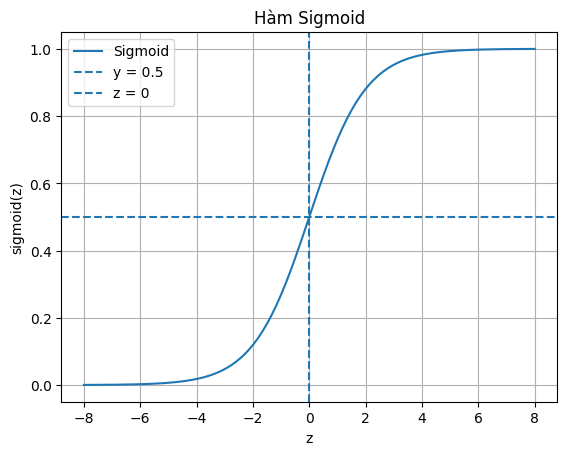

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Tạo các giá trị z từ -8 đến 8
z = np.linspace(-8, 8, 200)

# Tính giá trị sigmoid
sigmoid = 1 / (1 + np.exp(-z))

# Vẽ đồ thị sigmoid
plt.plot(z, sigmoid, label="Sigmoid")

# Vẽ đường ngang y = 0.5
plt.axhline(y=0.5, linestyle="--", label="y = 0.5")

# Vẽ đường dọc z = 0
plt.axvline(x=0, linestyle="--", label="z = 0")

# Đặt tên cho đồ thị
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.title("Hàm Sigmoid")

plt.legend()
plt.grid()

# Lưu hình
plt.savefig("sigmoid.png")

# Hiển thị đồ thị
plt.show()

Nhận xét: Đồ thị hàm sigmoid có dạng chữ S. Khi z càng âm thì giá trị sigmoid càng gần 0, còn khi z càng dương thì sigmoid càng gần 1. Tại z = 0 thì sigmoid bằng 0,5.

In [5]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("/content/sinh_vien.csv")

# Chọn biến đầu vào và nhãn
X = df[["gio_on"]]
y = df["qua_mon"]

# Khởi tạo và huấn luyện mô hình
mo_hinh = LogisticRegression()
mo_hinh.fit(X, y)


# Hàm dự đoán cho một sinh viên
def du_doan(gio):
    # Tạo dữ liệu đầu vào
    du_lieu_moi = pd.DataFrame({"gio_on": [gio]})

    # Tính xác suất qua môn
    xac_suat_qua_mon = mo_hinh.predict_proba(du_lieu_moi)[0, 1]

    # Dự đoán nhãn 0 hoặc 1
    nhan_du_doan = int(xac_suat_qua_mon >= 0.5)

    print("Số giờ ôn:", gio)
    print("Xác suất qua môn:", xac_suat_qua_mon)
    print("Dự đoán:", "Qua môn" if nhan_du_doan == 1 else "Rớt môn")


# Nhập số giờ ôn từ bàn phím
so_gio_onn = float(input("Nhập số giờ ôn: "))

du_doan(so_gio_onn)

Nhập số giờ ôn: 25
Số giờ ôn: 25.0
Xác suất qua môn: 0.9914699170001064
Dự đoán: Qua môn


Nhận xét: Mô hình dựa vào số giờ ôn để dự đoán khả năng qua môn. Số giờ ôn càng cao thì xác suất qua môn có xu hướng tăng. Mô hình lấy mức 0,5 làm ngưỡng để quyết định qua môn hay rớt môn.

Bài 4

In [6]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

df = pd.read_csv("/content/sinh_vien.csv")

X = df[["gio_on"]]
y = df["qua_mon"]

# Chia dữ liệu thành tập huấn luyện và tập kiểm tra
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=17,
    stratify=y
)

# Huấn luyện mô hình Logistic Regression
mo_hinh = LogisticRegression()
mo_hinh.fit(X_train, y_train)

# Lấy xác suất qua môn
xac_suat = mo_hinh.predict_proba(X_test)[:, 1]

# Chuyển xác suất thành nhãn với ngưỡng 0.5
y_pred = (xac_suat >= 0.5).astype(int)

# Lấy TP, TN, FP, FN từ confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("Ma trận nhầm lẫn:")
print(confusion_matrix(y_test, y_pred))

print("\nTP =", tp)
print("TN =", tn)
print("FP =", fp)
print("FN =", fn)

# Tính 4 chỉ số bằng công thức
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1_score = 2 * precision * recall / (precision + recall)

print("\nKết quả tính thủ công:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1_score:.4f}")

# Đối chiếu với kết quả của sklearn
print("\nClassification Report của sklearn:")
print(classification_report(y_test, y_pred, digits=4))

Ma trận nhầm lẫn:
[[ 9  3]
 [ 1 17]]

TP = 17
TN = 9
FP = 3
FN = 1

Kết quả tính thủ công:
Accuracy : 0.8667
Precision: 0.8500
Recall   : 0.9444
F1-score : 0.8947

Classification Report của sklearn:
              precision    recall  f1-score   support

           0     0.9000    0.7500    0.8182        12
           1     0.8500    0.9444    0.8947        18

    accuracy                         0.8667        30
   macro avg     0.8750    0.8472    0.8565        30
weighted avg     0.8700    0.8667    0.8641        30



Nhận xét: Mô hình được đánh giá qua 4 chỉ số Accuracy, Precision, Recall và F1-score. Accuracy cho biết tỷ lệ dự đoán đúng trên toàn bộ dữ liệu. Precision cho biết trong số các bạn được dự đoán qua môn thì có bao nhiêu bạn thực sự qua, còn Recall cho biết mô hình tìm ra được bao nhiêu bạn thực sự qua môn. F1-score giúp đánh giá sự cân bằng giữa Precision và Recall. Vì vậy, không nên chỉ nhìn vào Accuracy mà cần xem cả 4 chỉ số để đánh giá mô hình đầy đủ hơn.

In [ ]:
Bài 5

In [7]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score

df = pd.read_csv("/content/sinh_vien.csv")

X = df[["gio_on"]]
y = df["qua_mon"]

# Chia dữ liệu thành tập huấn luyện và kiểm tra
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=17,
    stratify=y
)

# Huấn luyện mô hình
mo_hinh = LogisticRegression()
mo_hinh.fit(X_train, y_train)

# Lấy xác suất qua môn
xac_suat = mo_hinh.predict_proba(X_test)[:, 1]

# Thử nhiều ngưỡng khác nhau
cac_nguong = [0.3, 0.5, 0.7]

for nguong in cac_nguong:
    # Tự đặt nhãn dự đoán theo threshold
    y_pred = (xac_suat >= nguong).astype(int)

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)

    print(f"\nNgưỡng = {nguong}")
    print(f"Precision = {precision:.4f}")
    print(f"Recall    = {recall:.4f}")


Ngưỡng = 0.3
Precision = 0.8500
Recall    = 0.9444

Ngưỡng = 0.5
Precision = 0.8500
Recall    = 0.9444

Ngưỡng = 0.7
Precision = 1.0000
Recall    = 0.8333


Nhận xét: Khi giảm ngưỡng từ 0,5 xuống 0,3, mô hình dễ dự đoán sinh viên qua môn hơn nên Recall có xu hướng tăng, nhưng Precision giảm do có thể dự đoán nhầm một số bạn rớt thành qua. Ngược lại, khi tăng ngưỡng lên 0,7, mô hình trở nên khó tính hơn nên Precision tăng nhưng Recall giảm. Vì vậy, việc chọn ngưỡng phụ thuộc vào mục đích của bài toán.

Bài 6

In [9]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

df = pd.read_csv("/content/sinh_vien.csv")

X = df[["gio_on"]]
y = df["qua_mon"]

# Chia dữ liệu thành tập huấn luyện và tập kiểm tra
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=17,
    stratify=y
)

# Huấn luyện mô hình
mo_hinh = LogisticRegression()
mo_hinh.fit(X_train, y_train)

# Xác suất qua môn
xac_suat_qua_mon = mo_hinh.predict_proba(X_test)[:, 1]

# Dự đoán ban đầu: 1 = qua môn
y_pred = (xac_suat_qua_mon >= 0.5).astype(int)

print("===== Positive class: QUA MÔN =====")
print("Ma trận nhầm lẫn:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Rớt môn", "Qua môn"],
    digits=4
))


# ==================================================
# ĐỔI POSITIVE CLASS
# 1 = Rớt môn
# 0 = Qua môn
# ==================================================

y_test_doi = 1 - y_test.to_numpy()
y_pred_doi = 1 - y_pred

print("\n===== Positive class: RỚT MÔN =====")
print("Ma trận nhầm lẫn:")
print(confusion_matrix(y_test_doi, y_pred_doi))

print("\nClassification Report:")
print(classification_report(
    y_test_doi,
    y_pred_doi,
    target_names=["Qua môn", "Rớt môn"],
    digits=4
))

===== Positive class: QUA MÔN =====
Ma trận nhầm lẫn:
[[ 9  3]
 [ 1 17]]

Classification Report:
              precision    recall  f1-score   support

     Rớt môn     0.9000    0.7500    0.8182        12
     Qua môn     0.8500    0.9444    0.8947        18

    accuracy                         0.8667        30
   macro avg     0.8750    0.8472    0.8565        30
weighted avg     0.8700    0.8667    0.8641        30


===== Positive class: RỚT MÔN =====
Ma trận nhầm lẫn:
[[17  1]
 [ 3  9]]

Classification Report:
              precision    recall  f1-score   support

     Qua môn     0.8500    0.9444    0.8947        18
     Rớt môn     0.9000    0.7500    0.8182        12

    accuracy                         0.8667        30
   macro avg     0.8750    0.8472    0.8565        30
weighted avg     0.8700    0.8667    0.8641        30



 Nhận xét: Khi đổi Positive class từ “qua môn” sang “rớt môn”, dữ liệu và mô hình không thay đổi nhưng ý nghĩa của các chỉ số đánh giá thay đổi. Precision và Recall lúc này tập trung vào khả năng dự đoán sinh viên rớt môn thay vì qua môn. Vì vậy, khi đánh giá mô hình cần xác định rõ lớp nào đang được xem là Positive.